<a href="https://colab.research.google.com/github/abeerahateeq/neurofive-ml-track/blob/main/Imbalanced_Data_Handling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from imblearn.over_sampling import SMOTE

In [10]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

df.drop("customerID", axis=1, inplace=True)

df = pd.get_dummies(
    df,
    drop_first=True
)
display(df.head())

/tmp/ipykernel_1250/4244913634.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [12]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

In [13]:
print(y.value_counts())

Churn_Yes
False    5174
True     1869
Name: count, dtype: int64


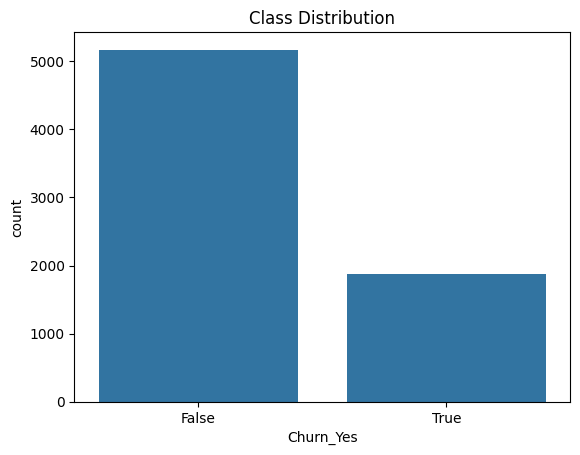

In [14]:
sns.countplot(x=y)

plt.title("Class Distribution")

plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [18]:
balanced_model = LogisticRegression(max_iter=1000)

balanced_model.fit(
    X_train_smote,
    y_train_smote
)

balanced_pred = balanced_model.predict(X_test)

print(classification_report(
    y_test,
    balanced_pred
))

              precision    recall  f1-score   support

       False       0.88      0.83      0.85      1036
        True       0.59      0.68      0.63       373

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
before = classification_report(
    y_test,
    pred,
    output_dict=True
)

after = classification_report(
    y_test,
    balanced_pred,
    output_dict=True
)

comparison = pd.DataFrame({

    "Metric":[
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Before":[
        before["True"]["precision"],
        before["True"]["recall"],
        before["True"]["f1-score"]
    ],

    "After":[
        after["True"]["precision"],
        after["True"]["recall"],
        after["True"]["f1-score"]
    ]

})

display(comparison)

,Metric,Before,After
0,Precision,0.685015,0.586207
1,Recall,0.600536,0.683646
2,F1 Score,0.640000,0.631188


## Why Accuracy Can Be Misleading

Accuracy measures the percentage of correct predictions made by a model. In imbalanced datasets, where one class is much more common than the other, a model can achieve high accuracy simply by predicting the majority class every time.

Metrics such as Precision, Recall, and F1-score provide a more complete picture of model performance because they evaluate how well the model identifies the minority class. For customer churn prediction, correctly identifying customers who are likely to leave is often more valuable than achieving a high overall accuracy.

## Model Performance Before and After SMOTE

| Metric | Before SMOTE | After SMOTE |
|---------|-------------:|------------:|
| Precision | **0.685** | **0.586** |
| Recall | **0.601** | **0.684** |
| F1 Score | **0.640** | **0.631** |

Applying SMOTE increased the model's recall, meaning it became better at identifying customers who were likely to churn. However, this improvement came at the cost of lower precision, as the model also produced more false positive predictions. Although the F1-score decreased slightly, the higher recall can be valuable in business scenarios where missing a customer who is likely to leave is more costly than contacting an additional customer who would have stayed.